# Introduction

This tutorial covers several libraries that can help to improve the performance of scientific Python code. We will cover:
- Why pure-Python code is slow
- Introduce three example use cases that we will use to compare the different approaches
- `numpy` (a Python library for vectorised array operations)
- `numba` (a Python library for just-in-time compilation of Python code to efficient machine code
- `cupy` (a Python library for running code on CUDA GPUs, with a numpy-like interface)
- Briefly mention some other libraries for further reading

We will not go into depth on how to maximise performance within each library, or cover the more advanced features of the libraries - the aim is to show the basic features of the libraries and how they can be used to easily improve the performance of Python code.

# Pure python
Why is python slow?
- Python is an interpreted language. Unlike compiled languages (e.g. C, C++, Java, Fortran), where a compiler reads all source code at once and translates to machine code, the Python interpreter reads one line of code at a time and translates to bytecode
    - Adds overhead (effectively compiling each time you run)
    - Less opportunity for optimisation
- Dynamic typing: Python variables are not explicitly typed, and functions must be able to handle any object types as input
    - Again, less opportunity for optimisation
    - At bytecode level, must be able to handle many unused edge cases
- Global Interpreter Lock (GIL): in CPython, only one thread at a time can execute Python bytecode
    - Effectively prevents multi-threaded code
    - GIL is released during I/O operations
    - Also released when libraries call external non-Python code (we will come back to this later)
    - As of Python 3.14, there is official support for free-threaded build

In [1]:
import math
import matplotlib.pyplot as plt
from utils import random_matrix

We now introduce three example use cases that we will use throughout this tutorial.

## Elementwise function: $\sin^2(x)+\cos(x)$

Case 1 is simple: apply a trigonometric function $\sin^2(x)+\cos(x)$ to every element $x$ in an array. In pure python we express our array as a list, and loop over the elements to apply our trigonometric function to each.

In [2]:
def sin_squared_plus_cos_python(x):
    """Evaluate sin(x)**2 + cos(x) element by element. Returns a new list."""
    out = []
    for i in range(len(x)):
        out.append(math.sin(x[i]) ** 2 + math.cos(x[i]))
    return out

Let's test on a list of points between 0 and $2\pi$

In [3]:
length_x = 10_000_000
x_python = [i*2*math.pi/(length_x-1) for i in range(length_x)]

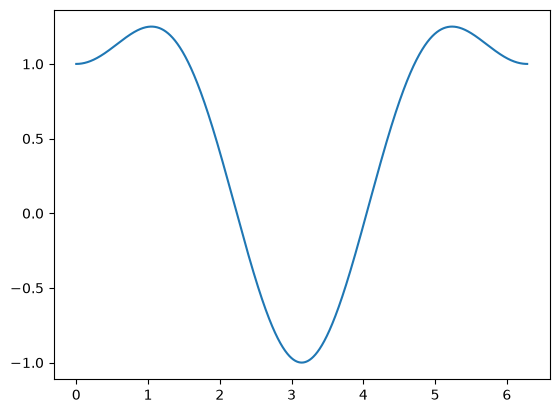

In [4]:
y_python = sin_squared_plus_cos_python(x_python)

plt.plot(x_python, y_python)

We can use the Jupyter `%timeit` magic to run this several times and time how long each iteration takes. Here we use the `-o` flag so that we can store the timing output in a variable for re-use later.

In [6]:
result = %timeit -o sin_squared_plus_cos_python(x_python)
ufunc_python_time = (result.average, result.stdev)

2.08 s ± 210 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Matrix-matrix multiplication

Case 2 is also very simple - matrix multiplication:
$$C_{ij}=\sum_{k}A_{ik}B_{kj}$$
We express our matrices as lists of lists. The implementation uses a triple for-loop over the $i$, $j$ and $k$ indices.

In [7]:
def matmul_python(A, B):
    """
    Matrix multiplication.
    Takes two matrices A and B (lists of lists) as input; returns matrix C=AB.
    """
    n = len(A)
    p = len(A[0])
    m = len(B[0])
    C = []
    for i in range(n):
        row = []
        for j in range(m):
            elem = 0.0
            for k in range(p):
                elem += A[i][k] * B[k][j]
            row.append(elem)
        C.append(row)
    return C

Let's test on square matrices of random values (we implemented a pure-python `random_matrix` function in the file 'utils.py' to help out here).

In [8]:
matrix_size = 300

A_python = random_matrix(matrix_size, matrix_size, seed=0)
B_python = random_matrix(matrix_size, matrix_size, seed=1)

In [9]:
C_python = matmul_python(A_python, B_python)

Again, time with `%timeit`

In [10]:
result = %timeit -o matmul_python(A_python, B_python)
matmul_python_time = (result.average, result.stdev)

1.34 s ± 4.67 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## 2D heat diffusion

Our final case is a bit more complex: 2-dimensional heat diffusion using the Jacobi stencil. This is an iterative process to update values on a grid based on the neighbouring values:
$$G_{i,j}(t+1)=\frac{G_{i-1,j}(t)+G_{i+1,j}(t)+G_{i,j-1}(t)+G_{i.j+1}(t)}{4}$$
Usually we would iterate this process until it converges (i.e. when the system reaches thermal equilibrium). Here, we will run for a fixed number of iterations - this is sufficient to illustrate our points.

It's interesting to note that this process is a convolution, similar to those used in Convolutional Neural Networks (which will be coming up in the PyTorch examples this afternoon).

We use a "ping-pong" double buffer approach for this implementation: the inner kernel function `jacobi_python` takes two grids (lists of lists) as input, calculates one Jacobi iteration on `grid_in` and writes the result to `grid_out`; the outer function `heat_diffusion_python` loops through iterations, and maintains two buffers that swap after each iteration (so the output of iteration $i$ becomes the input to iteration $i+1$).

The boundaries (i.e. the entries around the edges of the grid) are never updated - they remain fixed throughout the calculation.

In [11]:
def jacobi_python(grid_in, grid_out):
    """Run one sweep with a Jacobi stencil on input grid grid_in, writing diffused outputs to grid_out."""
    n = len(grid_in)
    m = len(grid_in[0])
    for i in range(1, n - 1):
        for j in range(1, m - 1):
            grid_out[i][j] = 0.25 * (grid_in[i - 1][j] + grid_in[i + 1][j] + grid_in[i][j - 1] + grid_in[i][j + 1])

def heat_diffusion_python(grid, n_iter):
    """
    2D heat diffusion. Run n_iter Jacobi iterations and return the final grid.
 
    Uses two buffers (ping-pong) so that each sweep reads only from the
    previous iterate. The input grid is not modified.
    """
    buffer1 = [row[:] for row in grid]   # current iterate
    buffer2 = [row[:] for row in grid]   # next iterate (boundary copied once, never changes)
    
    for _ in range(n_iter):
        jacobi_python(buffer1, buffer2)     # Run one Jacobi sweep
        buffer1, buffer2 = buffer2, buffer1 # swap buffers
    return buffer1

Let's test with a square grid - we'll keep the top edge at a value of 1, and all other edges at 0.

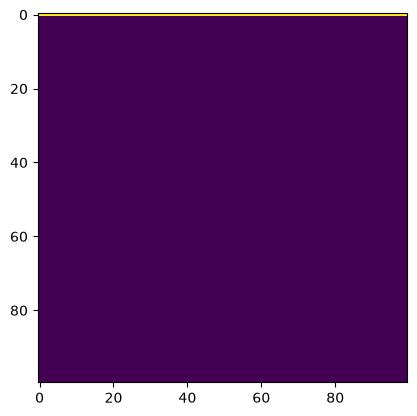

In [12]:
grid_size = 100
initial_grid_python = [[1.0]*grid_size] + [[0.0]*grid_size for _ in range(grid_size-1)]

plt.imshow(initial_grid_python)

Run for a number of iterations, and see how it looks.

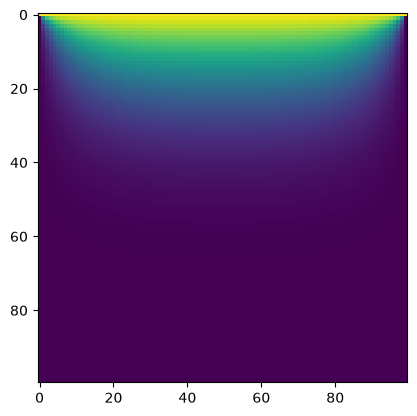

In [13]:
n_iter = 1000
diffused_grid_python = heat_diffusion_python(initial_grid_python, n_iter=n_iter)

plt.imshow(diffused_grid_python)

And now time it

In [14]:
result = %timeit -o heat_diffusion_python(initial_grid_python, n_iter=n_iter)
jacobi_python_time = (result.average, result.stdev)

1.08 s ± 3.71 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Numpy

`numpy` is a library for vectorised numerical operations on n-dimensional arrays (via the `numpy.ndarray` data type). Under the hood, numpy is a wrapper around fast compiled routines written in C. By writing vectorised code using numpy arrays instead of loops, all of the looping over elements is handled by these compiled routines instead of the Python interpreter, which is:
- faster (no interpreter overhead)
- optimised for SIMD vectorisation (memory-aligned homogeneous arrays)
- can use multi-threading as it avoids the GIL (although not all numpy operations are multi-threaded - it depends on the underlying library being used)

In [15]:
import numpy as np
from threadpoolctl import threadpool_limits

We can see information about the libraries and system information available to numpy by using `np.show_config()`:

In [16]:
np.show_config()

Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.14.6/lib/python3.14/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.14.6/lib/python3.14/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.34.106.0  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      Haswell MAX_THREADS=64
    pc file directory: /project/.openblas
    version: 0.3.34.106.0
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.14.6/lib/python3.14/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.14.6/lib/python3.14/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.34.106.0  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      Haswell MAX_THREADS=64
    pc file directory: /project/.openblas
    version: 0.3.34.106.0
Compilers:
  c:
    commands: cc
 

## Overview of numpy features

What do we mean by "vectorisation"? Let's consider what element-wise multiplication of two lists looks like in pure Python.

In [17]:
a_list = [1, 2, 3, 4, 5, 6]
b_list = [9, 8, 7, 0, -1, -2]
c_list = []
for i in range(len(a_list)):
    c_list.append(a_list[i]*b_list[i])

c_list

[9, 16, 21, 0, -5, -12]

We have to loop over the elements of the lists. Compare this to the vectorised implementation below using numpy arrays - multiplying two arrays automatically applies the multiplication operation to each element.

In [18]:
a_array = np.array(a_list)
b_array = np.array(b_list)
c_array = a_array*b_array

c_array

array([  9,  16,  21,   0,  -5, -12])

We can reshape arrays...

In [19]:
a_reshaped = a_array.reshape((3, 2))
a_reshaped

array([[1, 2],
       [3, 4],
       [5, 6]])

... but the number of elements after reshaping must be the same as at the start

In [20]:
a_array.reshape((4, 5))

ValueError: cannot reshape array of size 6 into shape (4,5)

We can use `-1` to automatically infer the length of one dimension based on the size of the input

In [21]:
a_array.reshape((2, -1))

array([[1, 2, 3],
       [4, 5, 6]])

We can transpose an array using the `.T` method

In [22]:
a_reshaped.T

array([[1, 3, 5],
       [2, 4, 6]])

Array slicing syntax can be used to select a sub-part ("slice") of an array

In [23]:
a_reshaped[1:, :]

array([[3, 4],
       [5, 6]])

In [24]:
a_reshaped[:, 0]

array([1, 3, 5])

In [25]:
a_array[1::2]

array([2, 4, 6])

In [26]:
a_array[::-1]

array([6, 5, 4, 3, 2, 1])

In [27]:
a_array[:-2]

array([1, 2, 3, 4])

The `np.random` module is useful for generating arrays of random numbers.  
(and yes, arrays can have more than 2 dimensions...)

In [28]:
random_array = np.random.random((2, 2, 2))
random_array

array([[[0.49642787, 0.27965537],
        [0.74649588, 0.50014541]],

       [[0.17603133, 0.09478498],
        [0.01222466, 0.47737072]]])

In [29]:
random_array.shape

(2, 2, 2)

The ellipsis (`...`) can be used during slicing to specify that we want to keep all elements along multiple dimensions

In [30]:
random_array[0, ...]

array([[0.49642787, 0.27965537],
       [0.74649588, 0.50014541]])

"Fancy indexing" allows more flexible sub-selection of array elements

In [31]:
a_array[[1, 2, 5]]

array([2, 3, 6])

Numpy ufuncs ("universal functions") operate element-by-element on arrays

In [32]:
np.sin(a_reshaped)

array([[ 0.84147098,  0.90929743],
       [ 0.14112001, -0.7568025 ],
       [-0.95892427, -0.2794155 ]])

Array broadcasting allows a scalar or length-1 dimension to be "broadcast" across the dimension(s) of another array in binary operations...

In [33]:
a_reshaped * 5

array([[ 5, 10],
       [15, 20],
       [25, 30]])

... but the array dimensions must be compatible (see [broadcasting rules](https://numpy.org/doc/stable/user/basics.broadcasting.html))

In [34]:
a_reshaped * b_array[:3]

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

New length-1 dimensions can be added to arrays using `np.newaxis` (or `None`)

In [35]:
a_reshaped * b_array[:3, None]

array([[ 9, 18],
       [24, 32],
       [35, 42]])

In [36]:
a_array[:, None].shape

(6, 1)

In [37]:
a_array[:, None] * b_array[None, :]

array([[  9,   8,   7,   0,  -1,  -2],
       [ 18,  16,  14,   0,  -2,  -4],
       [ 27,  24,  21,   0,  -3,  -6],
       [ 36,  32,  28,   0,  -4,  -8],
       [ 45,  40,  35,   0,  -5, -10],
       [ 54,  48,  42,   0,  -6, -12]])

As well as ufuncs, numpy has reduction functions (e.g. `sum`, `max`) that reduce an array to a single value along a specified axis

In [38]:
np.sum(a_reshaped)

np.int64(21)

In [39]:
np.sum(a_reshaped, axis=0)

array([ 9, 12])

In [40]:
np.max(a_reshaped, axis=1)

array([2, 4, 6])

Where possible, numpy operations return a "view" instead of a copy - so e.g. when taking a slice of an array, the returned array is in fact a view on a subset of the same memory in which the original array is stored - this avoids unnecessary overhead from memory copies. For full details of when numpy produces a view vs a copy, see [Copies and views](https://numpy.org/doc/stable/user/basics.copies.html).

The most reliable way to see whether one array is a view on another array is the `shares_memory` function.

In [41]:
np.shares_memory(a_array, a_reshaped)

True

We see that `a_reshaped` is actually a view on the same memory in which `a_array` is stored - this means that if we change an element of `a_reshaped`, `a_array` will also change.

In [42]:
a_reshaped[0, 0] = 5
a_array

array([5, 2, 3, 4, 5, 6])

Transposing an array also returns a view

In [43]:
np.shares_memory(a_array, a_reshaped.T)

True

**Watch out**: Reshaping _sometimes_ returns a view, but not always.

In [44]:
np.shares_memory(a_array, a_reshaped.T.reshape((6,)))

False

Fancy indexing (i.e. indexing with lists) always returns a copy, not a view

In [45]:
np.shares_memory(a_array, a_array[[1, 2, 5]])

False

If you need to be sure you have an independent copy of an array, use the `.copy()` method

In [46]:
np.shares_memory(a_array, a_array.copy())

False

Slicing always returns a view. Interesting to note that this is different to pure Python lists, where slice syntax is also supported but returns a copy.

In [47]:
mylist = [1, 2, 3]
mylist_sliced = mylist[:]
mylist_sliced[0] = 5
mylist

[1, 2, 3]

All ufuncs support in-place operations via the `out=` keyword argument. This writes the output to a specified pre-existing array instead of allocating and returning a new array, which is faster (although sometimes the difference may be negligible).

This also hapens implicitly with the `+=` operator: `x += 2` is equivalent to `np.add(x, 2, out=x)` (in-place), whereas `x = x + 2` is equivalent to `x = np.add(x, 2)` (i.e. not in-place - the result of `np.add(x, 2)` is written to a newly-allocated array before being assigned to the variable `x`).

In [48]:
test_in = np.linspace(0, 1, 100_000_000)
%time test_in = test_in + 2

CPU times: user 44.9 ms, sys: 63.7 ms, total: 109 ms
Wall time: 161 ms


In [49]:
%time test_in += 2

CPU times: user 49.2 ms, sys: 1.96 ms, total: 51.2 ms
Wall time: 50.1 ms


## Elementwise function: $\sin^2(x)+\cos(x)$
Using ufuncs, the vectorised implementation of our elementwise function is very simple.

In [50]:
def sin_squared_plus_cos_numpy(x):
    """Vectorised version of sin(x)**2 + cos(x) calculation, using numpy ufuncs."""
    return np.sin(x) ** 2 + np.cos(x)

We can use `np.linspace` to easily construct our input array of equally-spaced points between o and $2\pi$

In [51]:
x_numpy = np.linspace(0, 2*np.pi, length_x)

`np.allclose` is a convenient way to check the output of our function matches that of our original Python implementation (using `==` may fail due to small differences arising from floating-point precision, but `np.allclose` checks values are within a tolerance).

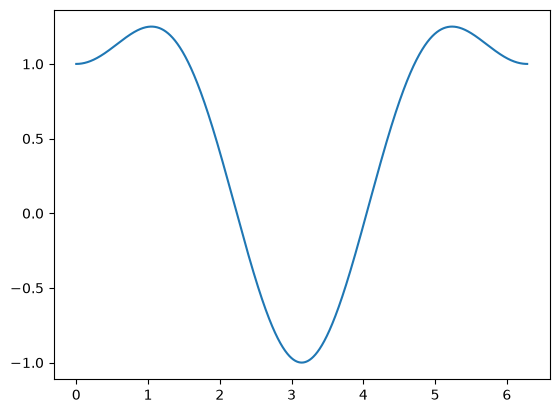

In [52]:
y_numpy = sin_squared_plus_cos_numpy(x_numpy)

assert np.allclose(y_numpy, y_python)

plt.plot(x_numpy, y_numpy)

Now we can time our vectorised implementation, and compare to the pure-Python original.

In [53]:
result = %timeit -o sin_squared_plus_cos_numpy(x_numpy)
ufunc_numpy_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_numpy_time[0]:.2f}x")

260 ms ± 392 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Speedup compared to pure python: 7.98x


## Matrix-matrix multiplication

Matrix-matrix multiplication is exceptionally simple - numpy has a built-in operator `@` for that.

Under the hood, this calls the BLAS DGEMM/SGEMM routine (double/single precision general matrix multiply), which is highly optimised and uses multi-threading.

In [54]:
def matmul_numpy(A, B):
    """
    Matrix multiplication with the '@' operator.
    
    Calls the (threaded) BLAS dgemm/sgemm that NumPy is linked against.
    """
    return A @ B

We could use `np.random` to generate our inputs, but here we re-use the original Python matrices (using `np.array()` to convert them to numpy arrays) so that we can exactly compare the same calculation and outputs.

In [55]:
A_numpy = np.array(A_python)
B_numpy = np.array(B_python)

Again, check our function produces the same output, then time it and compare with the pure-Python implementation.

In [56]:
C_numpy = matmul_numpy(A_numpy, B_numpy)

assert np.allclose(C_numpy, C_python)

In [57]:
result = %timeit -o matmul_numpy(A_numpy, B_numpy)
matmul_numpy_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_numpy_time[0]:.2f}x")

538 μs ± 251 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Speedup compared to pure python: 2486.67x


As an illustration, let's try implementing matrix multiplication ourselves using numpy broadcasting and reduction.

**Note**: Don't try this for very large arrays - it uses much more memory than either the `@` implementation or our original Pytohn implementation because it constructs a full $m\times n\times p$ array before summing.

This is just an illustration. In real usage, don't try implementing matrix multiplication yourself - you'll never beat BLAS.

In [58]:
def matmul_numpy_naive(A, B):
    """
    For comparison, an implementation of matrix multiplication using numpy
    array broadcasting and sum.
    
    In real use, don't do this - it uses more memory and avoids using the
    highly-optimised underlying BLAS implementation of matrix multiplication.
    """
    return np.sum(A[:, :, None] * B[None, :, :], axis=1)

In [59]:
C_numpy_naive = matmul_numpy_naive(A_numpy, B_numpy)

assert np.allclose(C_numpy_naive, C_python)

In [60]:
result = %timeit -o matmul_numpy_naive(A_numpy, B_numpy)
matmul_numpy_naive_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_numpy_naive_time[0]:.2f}x")
print(f"But matrix multiplication with matmul/@ is {matmul_numpy_naive_time[0]/matmul_numpy_time[0]:.2f}x faster still")

48.9 ms ± 182 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Speedup compared to pure python: 27.35x
But matrix multiplication with matmul/@ is 90.91x faster still


## 2D heat diffusion
The Jacobi stencil can be implemented neatly using array slicing.

The outer loop over iterations can't be vectorised, because each iteration depends on the previous one, so this remains as a Python loop.

In [61]:
def jacobi_numpy(grid):
    """
    Jacobi-stencil sweep, using numpy slicing instead of loops.
    
    Returns only the inner grid, without the boundary.
    """
    return 0.25 * (grid[:-2, 1:-1] + grid[2:, 1:-1] + grid[1:-1, :-2] + grid[1:-1, 2:])

def heat_diffusion_numpy(grid, n_iter):
    """
    2D heat diffusion. Run n_iter Jacobi iterations and return the final grid.
    """
    grid_out = grid.copy()
    for _ in range(n_iter):
        grid_out[1:-1, 1:-1] = jacobi_numpy(grid_out) # Run one Jacobi sweep
    return grid_out

W can create our initial condition using `np.zeros` to produce an array of all zeros, then use slicing to set the top row to 1.

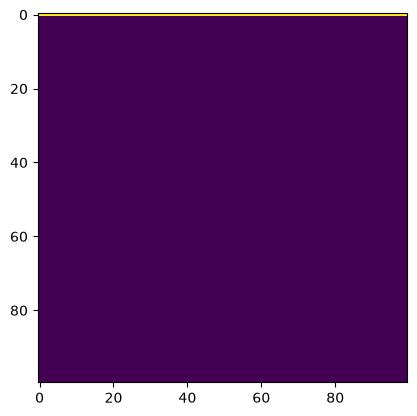

In [62]:
initial_grid_numpy = np.zeros((grid_size, grid_size))
initial_grid_numpy[0, :] = 1.0

plt.imshow(initial_grid_numpy)

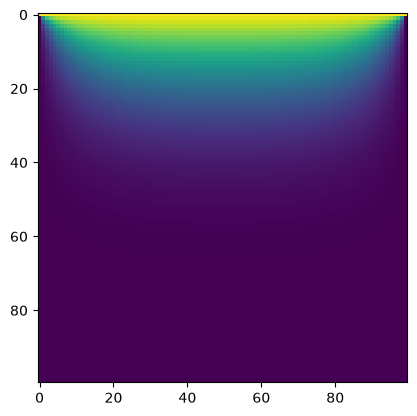

In [63]:
n_iter = 1000
diffused_grid_numpy = heat_diffusion_numpy(initial_grid_numpy, n_iter=n_iter)

assert np.allclose(diffused_grid_numpy, diffused_grid_python)

plt.imshow(diffused_grid_numpy)

In [64]:
result = %timeit -o heat_diffusion_numpy(initial_grid_numpy, n_iter=n_iter)
jacobi_numpy_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {jacobi_python_time[0]/jacobi_numpy_time[0]:.2f}x")

27.7 ms ± 136 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Speedup compared to pure python: 39.10x


## Scaling number of threads

Typically the number of threads used by the libraries that numpy is built on is cotrolled by the `OMP_NUM_THREADS`/`MKL_NUM_THREADS` environment variables. We can't easliy dynamically change that within the notebook, because what counts is the values of these environment variables when we `import numpy`.

Instead we'll use `threadpoolctl` to demonstrate impact of varying number of threads (you would rarely need to use this approach in real life - this is just for demonstration).

### Ufunc

In [65]:
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    with threadpool_limits(limits=num_threads):
        print(f"Using {num_threads} threads...")
        %timeit sin_squared_plus_cos_numpy(x_numpy)

Using 1 threads...
262 ms ± 1.77 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 2 threads...
261 ms ± 1.32 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 4 threads...
261 ms ± 2.07 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 8 threads...
260 ms ± 211 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 16 threads...
261 ms ± 448 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 32 threads...
261 ms ± 234 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 64 threads...
260 ms ± 238 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 128 threads...
261 ms ± 223 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


No speedup with increasing thread count - our numpy implementation is vectorised but _not_ parallelised.

### Matmul

In [66]:
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    with threadpool_limits(limits=num_threads):
        print(f"Using {num_threads} threads...")
        %timeit matmul_numpy(A_numpy, B_numpy)

Using 1 threads...
1.17 ms ± 19.5 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 2 threads...
903 μs ± 39.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 4 threads...
504 μs ± 11.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 8 threads...
541 μs ± 63.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 16 threads...
420 μs ± 17.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 32 threads...
499 μs ± 21 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 64 threads...
558 μs ± 26.6 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 128 threads...
554 μs ± 15.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


This time increasing the thread count _does_ speed up the execution (up to 16 threads) - so the BLAS routine underlying the numpy matrix _is_ multi-threaded.

In [69]:
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    with threadpool_limits(limits=num_threads):
        print(f"Using {num_threads} threads...")
        %timeit matmul_numpy_naive(A_numpy, B_numpy)

Using 1 threads...
48.5 ms ± 312 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 2 threads...
48.6 ms ± 139 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 4 threads...
48.7 ms ± 63 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 8 threads...
48.7 ms ± 24.4 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 16 threads...
48.8 ms ± 75.2 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 32 threads...
48.8 ms ± 110 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 64 threads...
53.2 ms ± 11 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 128 threads...
48.3 ms ± 634 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


But our naive implementation of matrix multiplication is not parallelised.

### Jacobi

In [70]:
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    with threadpool_limits(limits=num_threads):
        print(f"Using {num_threads} threads...")
        %timeit heat_diffusion_numpy(initial_grid_numpy, n_iter=n_iter)

Using 1 threads...
28.8 ms ± 44.8 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 2 threads...
28.8 ms ± 87.2 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 4 threads...
28.7 ms ± 47 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 8 threads...
29.7 ms ± 1.31 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 16 threads...
31.8 ms ± 236 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 32 threads...
36.7 ms ± 13.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 64 threads...
30.4 ms ± 930 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 128 threads...
29 ms ± 85.7 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


Also not parallel - so of our test cases, matrix multiplication is the only one that uses multi-threading in numpy.

# Numba

`numba` is a library that provides just-in-time (JIT) compilation of Python code. JIT means that the first time we run a function, numba takes the Python bytecode and compiles it into eficient machine code (using LLVM), then caches this for re-use the next time we call the same function (so the first run is slow, but afterwards it's much faster).

Using numba is very easy - everything is handled with decorators:
- `@jit` tells numba to JIT-compile a function
- `@jit(nopython=True)` tells numba to try to compile to code that doesn't use the Python interpreter at all, and fail if that's not possible. The alternative (`nopython=False`) would silently fall back to mixed outputs where only parts of the function are non-Python and the rest still runs via the Python interpreter, which is typically much less efficient. In recent versions of numba, `@jit(nopython=True)` is the default, but previously it wasn't so it's common to use `@njit` as a short-hand for `@jit(nopython=True)`.
- `@vectorize` takes a Python function that operates on scalar values and compiles it into a numpy ufunc which can handle arrays of any shape, complete with support for `out=` in-place operations.

Numba can also parallelise code - by replacing `range` with `prange` in a for loop and decorating with `@jit(parallel=True)`.

Numba is particularly useful for accelerating code with explicit loops and complex logic that cannot easily be expressed using vectorised numpy operations. But using numba to decorate numpy functions can also be beneficial (by fusing distinct ufunc operations together, and parallelising serial code).

**Note**: numba can only handle pure-python and numpy code. Other libraries are not supported.

In [71]:
from numba import njit, prange, vectorize, get_num_threads, set_num_threads

- Numba implementations of the three test cases - compare timings with pure python and numpy
    - With/without prange/parallel=True (probably just for one case)
    - Scaling with threads (NUMBA_NUM_THREADS)
    - Numba-ified numpy code as well as pure python
    - Show impact of jit - time first run separately, then %timeit afterwards (should be much faster)
    - Explain what we're seeing
        - ufunc: using numba to create "missing" numpy functions - a bit netter than numpy as avoids temporaries (perhaps also show that for just np.sin there's no difference between numpy and numba)
        - matmul: numba less good than numpy - BLAS highly-optimised, don't re-invent the wheel
        - jacobi: should be similar to numpy timing?

## Elementwise function: $\sin^2(x)+\cos(x)$
We have rewritten our original implementation to take a numpy array as input and initialise the output array using `np.empty_like` (which allocates memory for an array with the same shape and dtype as another specified array, without initialising the values) instead of building it up via successive `.append`s, but otherwise the logic is unchanged - we just add the `@njit` decorator.

In [72]:
@njit
def sin_squared_plus_cos_numba(x):
    """
    Evaluate sin(x)**2 + cos(x) element by element.
    """
    out = np.empty_like(x)
    for i in range(x.shape[0]):
        out[i] = math.sin(x[i]) ** 2 + math.cos(x[i])
    return out

Let's time the first run of our function separately

CPU times: user 7.04 s, sys: 487 ms, total: 7.53 s
Wall time: 24.3 s


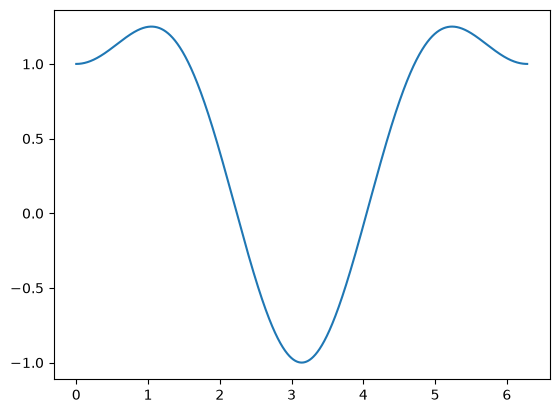

In [73]:
%time y_numba = sin_squared_plus_cos_numba(x_numpy)

assert np.allclose(y_numba, y_python)

plt.plot(x_numpy, y_numba)

In [74]:
result = %timeit -o sin_squared_plus_cos_numba(x_numpy)
ufunc_numba_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_numba_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_numba_time[0]:.2f}x")

173 ms ± 501 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Speedup compared to pure python: 12.04x
Speedup compared to numpy: 1.51x


We can see that the first run was a bit slower due to the JIT compilation, but following runs were faster.

This outperforms the numpy implementation, because the $\sin^2(x)+\cos(x)$ operation is calculated all at once on each element (whereas the numpy implementation first calculates `x1=sin(x)` and `x2=cos(x)`, then `x3=x1**2`, and finally `x4=x2+x3`, allocating a new array for each step).

We can equivalently use `@vectorize` to turn a scalar function into a numpy ufunc which works on arrays of any shape (note that we tell numba the input and output data types of the function).

In [75]:
@vectorize(["float64(float64)"])
def sin_squared_plus_cos_numba_vectorized(x):
    return math.sin(x) ** 2 + math.cos(x)

In [76]:
%time y_numba_vectorized = sin_squared_plus_cos_numba_vectorized(x_numpy)

assert np.allclose(y_numba_vectorized, y_python)

CPU times: user 168 ms, sys: 15 ms, total: 183 ms
Wall time: 670 ms


In [77]:
result = %timeit -o sin_squared_plus_cos_numba_vectorized(x_numpy)
ufunc_numba_vectorized_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_numba_vectorized_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_numba_vectorized_time[0]:.2f}x")

185 ms ± 29.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Speedup compared to pure python: 11.23x
Speedup compared to numpy: 1.41x


Timings are very similar to the `@njit` version.

Let's show our vectorized function can be used as a ufunc.

In [78]:
sin_squared_plus_cos_numba_vectorized(np.random.random((2, 2, 2)))

array([[[1.22894694, 1.18303522],
        [1.09428358, 1.2457732 ]],

       [[1.15870663, 1.01881717],
        [1.00057051, 1.17379027]]])

In [79]:
out = np.empty((2, 2, 2))
sin_squared_plus_cos_numba_vectorized(np.random.random((2, 2, 2)), out=out)
out

array([[[1.19500389, 1.18875169],
        [1.07176699, 1.19561558]],

       [[1.09279364, 1.03529566],
        [1.21925145, 1.19896768]]])

We can also try decorating our (already vectorised) numpy implementation with `@njit`.

In [80]:
@njit
def sin_squared_plus_cos_numpy_numba(x):
    """
    Evaluate sin(x)**2 + cos(x) element by element.
    """
    return np.sin(x) ** 2 + np.cos(x)

In [81]:
%time y_numpy_numba = sin_squared_plus_cos_numpy_numba(x_numpy)

assert np.allclose(y_numpy_numba, y_python)

CPU times: user 319 ms, sys: 136 ms, total: 455 ms
Wall time: 11.8 s


In [82]:
result = %timeit -o sin_squared_plus_cos_numpy_numba(x_numpy)
ufunc_numpy_numba_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_numpy_numba_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_numpy_numba_time[0]:.2f}x")

174 ms ± 3.99 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Speedup compared to pure python: 11.96x
Speedup compared to numpy: 1.50x


Again this outperforms numpy, for the same reason as before - numba can fuse the separate ufunc operations into a single elementwise operation.

Let's try parallelising - this is identical to our first numba implementation, except we swap `range` for `prange` in the for loop and add `parallel=True` to the decorator.

In [83]:
@njit(parallel=True)
def sin_squared_plus_cos_numba_parallel(x):
    out = np.empty_like(x)
    for i in prange(x.shape[0]):
        out[i] = math.sin(x[i]) ** 2 + math.cos(x[i])
    return out

In [84]:
%time y_numba_parallel = sin_squared_plus_cos_numba_parallel(x_numpy)

assert np.allclose(y_numba_parallel, y_python)

CPU times: user 2.76 s, sys: 412 ms, total: 3.18 s
Wall time: 13.1 s


In [85]:
result = %timeit -o sin_squared_plus_cos_numba_parallel(x_numpy)
ufunc_numba_parallel_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_numba_parallel_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_numba_parallel_time[0]:.2f}x")

7.46 ms ± 1.44 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
Speedup compared to pure python: 278.64x
Speedup compared to numpy: 34.90x


This is significantly faster again - we're now looping over the elements of our array in parallel, which numpy was unable to do.

Can we get the same speedup by decorating the numpy implementation with `parallel=True`?

In [86]:
@njit(parallel=True)
def sin_squared_plus_cos_numpy_numba_parallel(x):
    return np.sin(x) ** 2 + np.cos(x)

In [87]:
%time y_numpy_numba_parallel = sin_squared_plus_cos_numpy_numba_parallel(x_numpy)

assert np.allclose(y_numpy_numba_parallel, y_python)

CPU times: user 2.11 s, sys: 312 ms, total: 2.42 s
Wall time: 16.3 s


In [88]:
result = %timeit -o sin_squared_plus_cos_numpy_numba_parallel(x_numpy)
ufunc_numpy_numba_parallel_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_numpy_numba_parallel_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_numpy_numba_parallel_time[0]:.2f}x")

11.9 ms ± 4.53 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
Speedup compared to pure python: 175.17x
Speedup compared to numpy: 21.94x


Yes we can - and this time we didn't even need to use `prange`.

## Matrix-matrix multiplication

For the matrix-matrix multiplication we make similar changes again - accept numpy arrays as input and allocate the output array before starting the loop, but otherwise the logic is unchanged.

In [89]:
@njit
def matmul_numba(A, B):
    """
    Matrix multiplication.
    Takes two matrices A and B (numpy arrays) as input; returns matrix C=AB.
    """
    n, p = A.shape
    m = B.shape[1]
    C = np.empty((n, m), dtype=A.dtype)
    for i in range(n):
        for j in range(m):
            elem = 0.0
            for k in range(p):
                elem += A[i, k] * B[k, j]
            C[i, j] = elem
    return C

In [90]:
%time C_numba = matmul_numba(A_numpy, B_numpy)

assert np.allclose(C_numba, C_python)

CPU times: user 203 ms, sys: 130 ms, total: 333 ms
Wall time: 12 s


In [91]:
result = %timeit -o matmul_numba(A_numpy, B_numpy)
matmul_numba_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_numba_time[0]:.2f}x")
print(f"Speedup compared to numpy: {matmul_numpy_time[0]/matmul_numba_time[0]:.2f}x")

23.7 ms ± 90.2 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Speedup compared to pure python: 56.52x
Speedup compared to numpy: 0.02x


Much faster than the pure-python version, but still falling far short of the highly-optimised numpy matrix multiplication routine. Can we do better?

By switching the order of the loops, we can improve data locality, whcih improves cache re-use and makes the code more suitable for SIMD vectorisation.

In [92]:
@njit
def matmul_numba_ikj(A, B):
    """i-k-j order: the inner loop walks along rows of B and C (contiguous),
    which is much friendlier to the cache and to SIMD."""
    n, p = A.shape
    m = B.shape[1]
    C = np.zeros((n, m), dtype=A.dtype)
    for i in range(n):
        for k in range(p):
            for j in range(m):
                C[i, j] += A[i, k] * B[k, j]
    return C

In [93]:
%time C_numba_ikj = matmul_numba_ikj(A_numpy, B_numpy)

assert np.allclose(C_numba_ikj, C_python)

CPU times: user 226 ms, sys: 153 ms, total: 379 ms
Wall time: 12.2 s


In [94]:
result = %timeit -o matmul_numba_ikj(A_numpy, B_numpy)
matmul_numba_ikj_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_numba_ikj_time[0]:.2f}x")
print(f"Speedup compared to numpy: {matmul_numpy_time[0]/matmul_numba_ikj_time[0]:.2f}x")

3.64 ms ± 7.58 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Speedup compared to pure python: 367.90x
Speedup compared to numpy: 0.15x


Much better again, but still a long way off numpy. What if we parallelise it? (We've already seen that numpy matrix multiplication uses multi-threading)

In [95]:
@njit(parallel=True)
def matmul_numba_parallel(A, B):
    """i-k-j with the outer loop split across threads (each thread owns
    distinct rows of C, so there are no race conditions)."""
    n, p = A.shape
    m = B.shape[1]
    C = np.zeros((n, m), dtype=A.dtype)
    for i in prange(n):
        for k in range(p):
            for j in range(m):
                C[i, j] += A[i, k] * B[k, j]
    return C

In [96]:
%time C_numba_parallel = matmul_numba_parallel(A_numpy, B_numpy)

assert np.allclose(C_numba_parallel, C_python)

CPU times: user 3.47 s, sys: 1.16 s, total: 4.64 s
Wall time: 13.8 s


In [98]:
result = %timeit -o matmul_numba_parallel(A_numpy, B_numpy)
matmul_numba_parallel_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_numba_parallel_time[0]:.2f}x")
print(f"Speedup compared to numpy: {matmul_numpy_time[0]/matmul_numba_parallel_time[0]:.2f}x")

The slowest run took 28.17 times longer than the fastest. This could mean that an intermediate result is being cached.
1.74 ms ± 2.54 ms per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Speedup compared to pure python: 769.13x
Speedup compared to numpy: 0.31x


Another speedup, but still not as good as numpy.

What did I tell you? **Don't reinvent the wheel!** You will never beat BLAS at matrix multiplication.

## 2D heat diffusion

In [99]:
@njit
def jacobi_numba(grid_in, grid_out):
    n, m = grid_in.shape
    for i in range(1, n - 1):
        for j in range(1, m - 1):
            grid_out[i, j] = 0.25 * (
                grid_in[i - 1, j] + grid_in[i + 1, j] + grid_in[i, j - 1] + grid_in[i, j + 1]
            )

def heat_diffusion_numba(grid, n_iter):
    buffer1 = grid.copy()
    buffer2 = grid.copy()
    for _ in range(n_iter):
        jacobi_numba(buffer1, buffer2)
        buffer1, buffer2 = buffer2, buffer1
    return buffer1

CPU times: user 5.71 ms, sys: 2.18 ms, total: 7.89 ms
Wall time: 273 ms


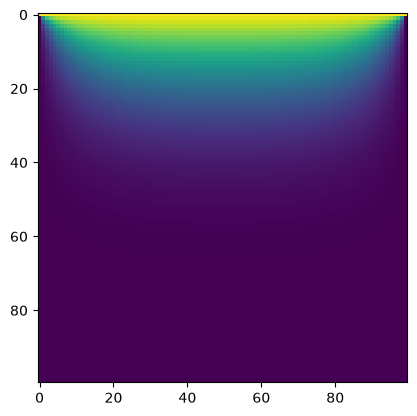

In [102]:
%time diffused_grid_numba = heat_diffusion_numba(initial_grid_numpy, n_iter=n_iter)

assert np.allclose(diffused_grid_numba, diffused_grid_python)

plt.imshow(diffused_grid_numba)

In [103]:
result = %timeit -o heat_diffusion_numba(initial_grid_numpy, n_iter=n_iter)
jacobi_numba_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {jacobi_python_time[0]/jacobi_numba_time[0]:.2f}x")
print(f"Speedup compared to numpy: {jacobi_numpy_time[0]/jacobi_numba_time[0]:.2f}x")

3.23 ms ± 5.08 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Speedup compared to pure python: 335.49x
Speedup compared to numpy: 8.58x


Significantly out-performing numpy on this one - again due to fusing operations, this time within the Jacobi kernel.

What if we parallelise it?

In [104]:
@njit(parallel=True)
def jacobi_numba_parallel(grid_in, grid_out):
    n, m = grid_in.shape
    for i in prange(1, n - 1):
        for j in range(1, m - 1):
            grid_out[i, j] = 0.25 * (
                grid_in[i - 1, j] + grid_in[i + 1, j] + grid_in[i, j - 1] + grid_in[i, j + 1]
            )

def heat_diffusion_numba_parallel(grid, n_iter):
    buffer1 = grid.copy()
    buffer2 = grid.copy()
    for _ in range(n_iter):
        jacobi_numba_parallel(buffer1, buffer2)
        buffer1, buffer2 = buffer2, buffer1
    return buffer1

In [105]:
%time diffused_grid_numba_parallel = heat_diffusion_numba_parallel(initial_grid_numpy, n_iter=n_iter)

assert np.allclose(diffused_grid_numba_parallel, diffused_grid_python)

CPU times: user 14min 55s, sys: 831 ms, total: 14min 55s
Wall time: 18.6 s


In [107]:
result = %timeit -o heat_diffusion_numba_parallel(initial_grid_numpy, n_iter=n_iter)
jacobi_numba_parallel_time = (result.average, result.stdev)

print(f"Speedup compared to pure python: {jacobi_python_time[0]/jacobi_numba_parallel_time[0]:.2f}x")
print(f"Speedup compared to numpy: {jacobi_numpy_time[0]/jacobi_numba_parallel_time[0]:.2f}x")

82.2 ms ± 2.34 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Speedup compared to pure python: 13.17x
Speedup compared to numpy: 0.34x


Now it's slower! What's going on?

We can't parallelise the outer loop, so we end up launching threads within each iteration - this has an associated overhead, and for the grid size we're using here the speedup from parallel iteration over the grid elements isn't sufficient to outweigh the overhead of launching threads. If we increased the grid size, at some point we would likely start to see a speedup from parallelisation.

## Scaling number of threads

We can use the numba `set_num_threads` function to see the impact of running with different thread counts.

In [108]:
get_num_threads()

128

### Ufunc

In [109]:
original_threadcount = get_num_threads()
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    set_num_threads(num_threads)
    print(f"Using {num_threads} threads...")
    %timeit sin_squared_plus_cos_numba_parallel(x_numpy)
set_num_threads(original_threadcount)

Using 1 threads...
174 ms ± 737 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using 2 threads...
94.3 ms ± 241 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 4 threads...
48.1 ms ± 1.52 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 8 threads...
24.3 ms ± 139 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 16 threads...
13.5 ms ± 2.11 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 32 threads...
12.9 ms ± 3.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 64 threads...
7.47 ms ± 2.75 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 128 threads...
8.85 ms ± 2.07 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


Unlike numpy, this one _is_ parallelised.

### Matmul

In [110]:
original_threadcount = get_num_threads()
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    set_num_threads(num_threads)
    print(f"Using {num_threads} threads...")
    %timeit matmul_numba_parallel(A_numpy, B_numpy)
set_num_threads(original_threadcount)

Using 1 threads...
3.62 ms ± 36.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 2 threads...
1.94 ms ± 13.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 4 threads...
1.03 ms ± 21.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 8 threads...
553 μs ± 8.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 16 threads...
355 μs ± 28.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 32 threads...
278 μs ± 38 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 64 threads...
380 μs ± 18.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using 128 threads...
The slowest run took 36.13 times longer than the fastest. This could mean that an intermediate result is being cached.
2.1 ms ± 4.28 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


This is also parallelised, but never as fast as numpy.

### Jacobi

In [112]:
original_threadcount = get_num_threads()
for num_threads in (1, 2, 4, 8, 16, 32, 64, 128):
    set_num_threads(num_threads)
    print(f"Using {num_threads} threads...")
    %timeit heat_diffusion_numba_parallel(initial_grid_numpy, n_iter=n_iter)
set_num_threads(original_threadcount)

Using 1 threads...
4.37 ms ± 1.98 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 2 threads...
7.34 ms ± 213 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 4 threads...
8.05 ms ± 12.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 8 threads...
14.3 ms ± 2.51 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 16 threads...
17.2 ms ± 723 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using 32 threads...
22.4 ms ± 1.36 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 64 threads...
35.7 ms ± 2.07 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Using 128 threads...
91.2 ms ± 12.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This one gets slower as we increase the thread count - the overhead of launching threads dominates here.

# CuPy
`cupy` is a library that aims to provide a drop-in replacement for numpy and scipy for computing on NVIDIA GPUs (and also with experimental support for AMD GPUs).

What is a GPU? I won't go into detail (part of the aim of cupy is that users should be able to use it without a detailed knowledge of the underlying hardware), but you can think of a GPU as being somewhat like a CPU but with a very large number of not-very-powerful cores (as opposed to a small number of fast cores, as we would find on a CPU). Some key points:
- GPUs are more efficient than CPUs in terms of power per FLOP
- GPUs typically operate on distinct memory from the host machine, so data must be copied to/from the GPU device (which adds overhead)
- GPU memory is typically smaller than CPU memory
- Each function executed on an NVIDIA GPU is a CUDA kernel - launching a kernel on the GPU adds more overhead
- GPUs perform best on highly data-parallel applications - a top-end GPU needs hundreds of thousands of threads to saturate performance
- Computation on the GPU happens asynchronously - writing code that forces regular synchronisation between the host and device can negatively impact performance

The cupy API is essentially identical to numpy - just replace `np` with `cp`, and then numpy functions can be directly used with cupy. But there are some differences to keep in mind:
- There is a distinction between host and device arrays - device arrays live in the GPU device memory, and are the only arrays that can be used in GPU computation; host arrays (numpy arrays) live in the host memory and are the only arrays that the surrounding Python code can interact with. Copying data between host and device arrays (`cp.asarray(numpy_array)` to copy to device, `device_array.get()` or `cp.asnumpy(device_array)` to copy back to host) adds overhead.
- We can't straightforwardly use `%timeit` to time GPU execution because it's asynchronous - we would only time the kernel launch overhead. Instead we use `cupyx.profiler.benchmark`, which handles the synchronisation for us.
- cupy can be used to create custom CUDA kernels via `ElementwiseKernel`, `ReductionKernel`, `RawKernel` and `@fuse` (we won't cover these today).

Aside: `numba` can also compile for GPUs (via the `numba-cuda` library). This provides more low-level functionality, to directly define custom CUDA kernels using Python code. We won't cover this today.

In [113]:
import cupy as cp
from cupyx.profiler import benchmark

We can check how many GPUs are available using `cp.cuda.runtime.getDeviceCount()`

In [114]:
cp.cuda.runtime.getDeviceCount()

4

`cp.cuda.runtime.getDeviceProperties(0)` gives us an overview of the first of these GPUs

In [115]:
cp.cuda.runtime.getDeviceProperties(0)

{'name': b'NVIDIA A100-SXM4-40GB',
 'totalGlobalMem': 42600300544,
 'sharedMemPerBlock': 49152,
 'regsPerBlock': 65536,
 'warpSize': 32,
 'maxThreadsPerBlock': 1024,
 'maxThreadsDim': (1024, 1024, 64),
 'maxGridSize': (2147483647, 65535, 65535),
 'clockRate': 1410000,
 'totalConstMem': 65536,
 'major': 8,
 'minor': 0,
 'textureAlignment': 512,
 'texturePitchAlignment': 32,
 'multiProcessorCount': 108,
 'kernelExecTimeoutEnabled': 0,
 'integrated': 0,
 'canMapHostMemory': 1,
 'computeMode': 0,
 'maxTexture1D': 131072,
 'maxTexture2D': (131072, 65536),
 'maxTexture3D': (16384, 16384, 16384),
 'concurrentKernels': 1,
 'ECCEnabled': 1,
 'pciBusID': 3,
 'pciDeviceID': 0,
 'pciDomainID': 0,
 'tccDriver': 0,
 'memoryClockRate': 1215000,
 'memoryBusWidth': 5120,
 'l2CacheSize': 41943040,
 'maxThreadsPerMultiProcessor': 2048,
 'isMultiGpuBoard': 0,
 'cooperativeLaunch': 1,
 'cooperativeMultiDeviceLaunch': 1,
 'maxTexture1DMipmap': 32768,
 'maxTexture1DLayered': (32768, 2048),
 'maxTexture2DMipm

`cp.cuda.Device().mem_info` tells us how much free memory (and total memory) is available on the GPU.

In [117]:
cp.cuda.Device().mem_info

(42155835392, 42600300544)

## Elementwise function: $\sin^2(x)+\cos(x)$
This is virtually identical to our numpy implementation - we just replace `np` with `cp`.

In [118]:
def sin_squared_plus_cos_cupy(x):
    return cp.sin(x) ** 2 + cp.cos(x)

Before we can run our function on the GPU, we have to transfer the input array to the GPU using `cp.asarray`.

In [119]:
x_gpu = cp.asarray(x_numpy)

To compare the output with our original result from Python, we first have to transfer the output back to the host using `cp.asnumpy` or `.get()`.

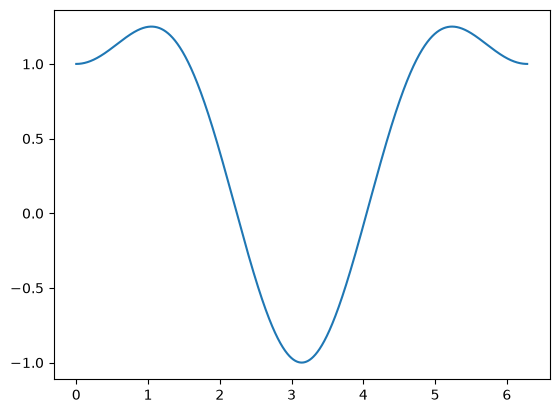

In [120]:
y_gpu = sin_squared_plus_cos_cupy(x_gpu)
y_cpu = cp.asnumpy(y_gpu)

assert np.allclose(y_cpu, y_python)

plt.plot(x_numpy, y_cpu)

First, let's time just the on-device computation (using `cupyx.profiler.benchmark` to handle the device synchronisation).

In [123]:
result = benchmark(sin_squared_plus_cos_cupy, (x_gpu,), n_repeat=25)
print(result)
ufunc_cupy_notransfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_cupy_notransfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_cupy_notransfer_time[0]:.2f}x")

sin_squared_plus_cos_cupy:    CPU:    51.084 us   +/- 20.792 (min:    42.251 / max:   128.080) us     GPU-0:   556.483 us   +/-  9.589 (min:   550.912 / max:   598.016) us
Speedup compared to pure python: 40703.26x
Speedup compared to numpy: 5098.08x


Enormously faster than numpy - but remember this doesn't include memory transfer overhead.

And now time again, this time including the overhead of transferring the data to/from the GPU memory.

In [126]:
def including_transfer(x):
    return cp.asnumpy(sin_squared_plus_cos_cupy(cp.asarray(x)))

result = benchmark(including_transfer, (x_numpy,), n_repeat=25)
print(result)
ufunc_cupy_transfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_cupy_transfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_cupy_transfer_time[0]:.2f}x")

including_transfer  :    CPU: 22825.845 us   +/- 74.396 (min: 22761.267 / max: 23154.877) us     GPU-0: 22841.185 us   +/- 75.519 (min: 22774.849 / max: 23169.600) us
Speedup compared to pure python: 91.09x
Speedup compared to numpy: 11.41x


Still an order of magnitude faster than numpy, but we can see the time is dominated by memory transfer. If we had a situation where we could perform many successive operations on the same array on the GPU without transferring back to host memory, we could get much better performance from the GPU.

Similar to what we did with numba earlier, we can use `@cp.fuse()` to fuse our $\sin^2(x)+\cos(x)$ operation into a single CUDA kernel (otherwise each operation requires a separate kernel).

In [127]:
@cp.fuse()
def sin_squared_plus_cos_cupy_fused(x):
    """cp.fuse compiles the whole expression into a single kernel: one read
    of x, one write of the result, no temporaries."""
    return cp.sin(x) ** 2 + cp.cos(x)

In [128]:
y_gpu = sin_squared_plus_cos_cupy_fused(x_gpu)
y_cpu = cp.asnumpy(y_gpu)

assert np.allclose(y_cpu, y_python)

In [129]:
result = benchmark(sin_squared_plus_cos_cupy_fused, (x_gpu,), n_repeat=25)
print(result)
ufunc_cupy_fuse_notransfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_cupy_fuse_notransfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_cupy_fuse_notransfer_time[0]:.2f}x")

sin_squared_plus_cos_cupy_fused:    CPU:    15.192 us   +/- 10.169 (min:    11.440 / max:    60.270) us     GPU-0:   366.797 us   +/-  9.095 (min:   362.496 / max:   406.528) us
Speedup compared to pure python: 136870.21x
Speedup compared to numpy: 17143.00x


This is many times faster again than the first cupy implementation - the impact of fusing is significant. But again, this excludes the memory transfer cost.

In [131]:
def including_transfer(x):
    return cp.asnumpy(sin_squared_plus_cos_cupy_fused(cp.asarray(x)))

result = benchmark(including_transfer, (x_numpy,), n_repeat=25)
print(result)
ufunc_cupy_fuse_transfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {ufunc_python_time[0]/ufunc_cupy_fuse_transfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {ufunc_numpy_time[0]/ufunc_cupy_fuse_transfer_time[0]:.2f}x")

including_transfer  :    CPU: 22619.282 us   +/- 31.097 (min: 22580.076 / max: 22728.146) us     GPU-0: 22634.129 us   +/- 31.491 (min: 22595.392 / max: 22744.543) us
Speedup compared to pure python: 91.92x
Speedup compared to numpy: 11.51x


As expected, the performance improvement from the fuse is insignificant compared to the transfer time - the bottleneck here is memory transfer.

## Matrix-matrix multiplication
This time we don't need to write a new function at all - `matmul_numpy` doesn't explicitly call any numpy library functions, so we can directly use it with cupy.

In [132]:
A_gpu = cp.asarray(A_numpy)
B_gpu = cp.asarray(B_numpy)

In [133]:
C_gpu = matmul_numpy(A_gpu, B_gpu)
C_cpu = cp.asnumpy(C_gpu)

assert np.allclose(C_cpu, C_python)

In [134]:
result = benchmark(matmul_numpy, (A_gpu, B_gpu), n_repeat=25)
print(result)
matmul_cupy_notransfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_cupy_notransfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {matmul_numpy_time[0]/matmul_cupy_notransfer_time[0]:.2f}x")

matmul_numpy        :    CPU:    22.496 us   +/-  5.497 (min:    20.160 / max:    47.820) us     GPU-0:    36.291 us   +/-  5.318 (min:    33.792 / max:    61.440) us
Speedup compared to pure python: 59465.66x
Speedup compared to numpy: 23.91x


Substantially better than numpy, but nowhere near as much so as with the ufunc case. The size of the matrix has an impact here - a larger matrix would be more parallelisable on the GPU.

In [135]:
def including_transfer(A, B):
    return cp.asnumpy(matmul_numpy(cp.asarray(A), cp.asarray(B)))

result = benchmark(including_transfer, (A_numpy, B_numpy), n_repeat=25)
print(result)
matmul_cupy_transfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {matmul_python_time[0]/matmul_cupy_transfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {matmul_numpy_time[0]/matmul_cupy_transfer_time[0]:.2f}x")

including_transfer  :    CPU:   253.605 us   +/-  6.956 (min:   248.930 / max:   279.890) us     GPU-0:   258.870 us   +/-  7.110 (min:   253.888 / max:   285.664) us
Speedup compared to pure python: 5274.91x
Speedup compared to numpy: 2.12x


Again transfer costs dominate.

## 2D heat diffusion
Again, `jacobi_numpy` and `heat_diffusion_numpy` can be used directly with cupy, so no need for a new function here.

In [136]:
initial_grid_gpu = cp.asarray(initial_grid_numpy)

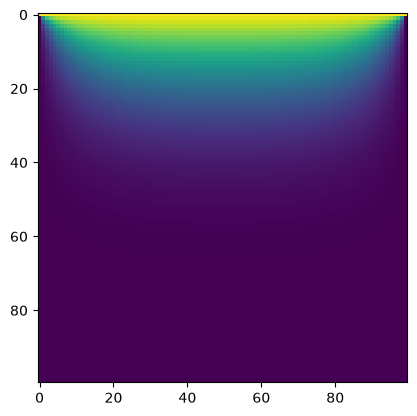

In [137]:
diffused_grid_gpu = heat_diffusion_numpy(initial_grid_gpu, n_iter=n_iter)
diffused_grid_cpu = cp.asnumpy(diffused_grid_gpu)

assert np.allclose(diffused_grid_cpu, diffused_grid_python)

plt.imshow(diffused_grid_numpy)

In [138]:
result = benchmark(heat_diffusion_numpy, (initial_grid_gpu, n_iter), n_repeat=25)
print(result)
jacobi_cupy_notransfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {jacobi_python_time[0]/jacobi_cupy_notransfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {jacobi_numpy_time[0]/jacobi_cupy_notransfer_time[0]:.2f}x")

heat_diffusion_numpy:    CPU: 79992.894 us   +/- 2813.683 (min: 77144.412 / max: 85201.897) us     GPU-0: 80001.556 us   +/- 2812.782 (min: 77152.252 / max: 85210.114) us
Speedup compared to pure python: 13.54x
Speedup compared to numpy: 0.35x


This one is _slower_ than numpy, even before accounting for memory transfer. The size of the grid is an important factor here - 100x100 gives work for a maximum of 10,000 threads, which is not enough to saturate the GPU.

In [139]:
def including_transfer(grid, n_iter):
    return cp.asnumpy(heat_diffusion_numpy(cp.asarray(grid), n_iter=n_iter))

result = benchmark(including_transfer, (initial_grid_gpu, n_iter), n_repeat=25)
print(result)
jacobi_cupy_transfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {jacobi_python_time[0]/jacobi_cupy_transfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {jacobi_numpy_time[0]/jacobi_cupy_transfer_time[0]:.2f}x")

including_transfer  :    CPU: 85143.399 us   +/- 3104.631 (min: 79254.100 / max: 87478.796) us     GPU-0: 85149.964 us   +/- 3104.525 (min: 79260.323 / max: 87486.046) us
Speedup compared to pure python: 12.72x
Speedup compared to numpy: 0.33x


Memory transfer cost is not so significant here, as we'd expect - we transfer the data once at the start, then keep it on the device throughout all iterations.

To illustrate a potential pitfall, let's put in a stopping condition - if the grid doesn't change significantly from one iteration to the next, then the system has reached equilibrium and we stop iterating.

This requires an error check after each iteration - that check forces synchronisation between the device and host, which impacts the performance.

In [141]:
def heat_diffusion_cupy_convergence_check(grid, n_iter, tol=1e-5):
    """
    2D heat diffusion. Run n_iter Jacobi iterations and return the final grid.

    Early-stopping condition if max change from last iteration is less than tol.
    """
    grid_out = grid.copy()
    buffer = cp.empty_like(grid_out[1:-1, 1:-1])
    for it in range(n_iter):
        buffer = jacobi_numpy(grid_out) # Run one Jacobi sweep
        err = float(cp.abs(buffer - grid_out[1:-1, 1:-1]).max())  # This line forces a GPU sync
        if err < tol:
            print(f"Converged after {it} iterations")
            grid_out[1:-1, 1:-1] = buffer
            return grid_out
        grid[1:-1, 1:-1] = buffer
    return grid_out

In [143]:
result = benchmark(heat_diffusion_cupy_convergence_check, (initial_grid_gpu, n_iter), n_repeat=25)
print(result)
jacobi_cupy_converge_notransfer_time = result.cpu_times.mean(), result.cpu_times.std(ddof=1)

print(f"Speedup compared to pure python: {jacobi_python_time[0]/jacobi_cupy_converge_notransfer_time[0]:.2f}x")
print(f"Speedup compared to numpy: {jacobi_numpy_time[0]/jacobi_cupy_converge_notransfer_time[0]:.2f}x")

heat_diffusion_cupy_convergence_check:    CPU: 182966.175 us   +/- 6402.589 (min: 172970.639 / max: 189670.937) us     GPU-0: 182973.932 us   +/- 6402.594 (min: 172977.158 / max: 189677.567) us
Speedup compared to pure python: 5.92x
Speedup compared to numpy: 0.15x


# Comparison

Run a systematic sweep over input array sizes for the various test cases:

In [ ]:
import json

# Parameters

OUTFILE = "benchmark_results.json"
SIZES = {
    "ufunc": [10**4, 10**5, 10**6, 10**7, 10**8],
    "matmul": [64, 128, 256, 512, 1024, 2048, 4096],
    "jacobi": [64, 128, 256, 512, 1024, 2048, 4096],
}
N_ITER = 25

# Input generators

def make_ufunc_input(N):
    return np.linspace(0.0, 2*np.pi, N)

def make_matmul_input(N):
    rng = np.random.default_rng(0)
    return rng.random((N, N)), rng.random((N, N))

def make_jacobi_input(N):
    grid = np.zeros((N, N))
    grid[0, :] = 1.0
    return grid

# Timing helpers

def time_cpu(func, args):
    result = %timeit -o func(*args)
    return {"average": result.average, "stdev": result.stdev}

def time_gpu(run, args, n_repeat=30):
    result = benchmark(run, args, n_repeat=n_repeat)
    return {"average": result.cpu_times.mean(), "stdev": result.cpu_times.std(ddof=1) if len(result.cpu_times) > 1 else np.nan}

def write_times(times, filename):
    with open(filename, 'w') as f:
        json.dump(times, f, indent=4)

# Run benchmarks

try:
    # Try loading previous times from file - we won't re-run those that are already complete
    with open(OUTFILE, 'r') as f:
        times = json.load(f)
except FileNotFoundError:
    times = {
        usecase: {impl: {} for impl in ["python", "numpy", "numba_serial", "numba_parallel", "cuda_notransfer", "cuda_withtransfer"]}
        for usecase in ["ufunc", "matmul", "jacobi"]
    }

cp.get_default_memory_pool().free_all_blocks()

usecase = "ufunc"
print(usecase)
for input_size in SIZES[usecase]:
    print(input_size)
    input_x = make_ufunc_input(input_size)
    
    impl = "python"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_cpu(sin_squared_plus_cos_python, (input_x.tolist(),))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numpy"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_cpu(sin_squared_plus_cos_numpy, (input_x,))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numba_serial"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        sin_squared_plus_cos_numba(input_x) # Warmup
        times[usecase][impl][input_size] = time_cpu(sin_squared_plus_cos_numba, (input_x,))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numba_parallel"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        sin_squared_plus_cos_numba_parallel(input_x) # Warmup
        times[usecase][impl][input_size] = time_cpu(sin_squared_plus_cos_numba_parallel, (input_x,))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "cuda_notransfer"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_gpu(sin_squared_plus_cos_cupy_fused, (cp.asarray(input_x),))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "cuda_withtransfer"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_gpu(lambda x: cp.asnumpy(sin_squared_plus_cos_cupy_fused(cp.asarray(x))), (input_x,))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    cp.get_default_memory_pool().free_all_blocks()

usecase = "matmul"
print(usecase)
for input_size in SIZES[usecase]:
    print(input_size)
    input_A, input_B = make_matmul_input(input_size)
    
    impl = "python"
    print(impl)
    if input_size > 1000:
        # Takes too long
        print("Too big - skipping.")
    elif input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_cpu(matmul_python, (input_A.tolist(), input_B.tolist()))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numpy"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_cpu(matmul_numpy, (input_A, input_B))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numba_serial"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        matmul_numba_ikj(input_A, input_B) # Warmup
        times[usecase][impl][input_size] = time_cpu(matmul_numba_ikj, (input_A, input_B))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numba_parallel"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        matmul_numba_parallel(input_A, input_B) # Warmup
        times[usecase][impl][input_size] = time_cpu(matmul_numba_parallel, (input_A, input_B))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "cuda_notransfer"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_gpu(matmul_numpy, (cp.asarray(input_A), cp.asarray(input_B)))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "cuda_withtransfer"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_gpu(lambda A, B: cp.asnumpy(matmul_numpy(cp.asarray(A), cp.asarray(B))), (input_A, input_B))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    cp.get_default_memory_pool().free_all_blocks()

usecase = "jacobi"
print(usecase)
for input_size in SIZES[usecase]:
    print(input_size)
    input_grid = make_jacobi_input(input_size)
    
    impl = "python"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_cpu(heat_diffusion_python, (input_grid.tolist(), N_ITER))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numpy"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_cpu(heat_diffusion_numpy, (input_grid, N_ITER))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numba_serial"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        heat_diffusion_numba(input_grid, N_ITER) # Warmup
        times[usecase][impl][input_size] = time_cpu(heat_diffusion_numba, (input_grid, N_ITER))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "numba_parallel"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        heat_diffusion_numba_parallel(input_grid, N_ITER) # Warmup
        times[usecase][impl][input_size] = time_cpu(heat_diffusion_numba_parallel, (input_grid, N_ITER))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "cuda_notransfer"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_gpu(heat_diffusion_numpy, (cp.asarray(input_grid), N_ITER))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    impl = "cuda_withtransfer"
    print(impl)
    if input_size not in times[usecase][impl] and str(input_size) not in times[usecase][impl]:
        times[usecase][impl][input_size] = time_gpu(lambda grid, n_iter: cp.asnumpy(heat_diffusion_numpy(cp.asarray(grid), n_iter)), (input_grid, N_ITER))
        write_times(times, OUTFILE)
    else:
        print("Already run. Skipping.")

    cp.get_default_memory_pool().free_all_blocks()

with open(OUTFILE, 'w') as f:
    json.dump(times, f, indent=4)


ufunc
10000
python
Already run. Skipping.
numpy
Already run. Skipping.
numba_serial
Already run. Skipping.
numba_parallel
Already run. Skipping.
cuda_notransfer
Already run. Skipping.
cuda_withtransfer
Already run. Skipping.
100000
python
Already run. Skipping.
numpy
Already run. Skipping.
numba_serial
Already run. Skipping.
numba_parallel
Already run. Skipping.
cuda_notransfer
Already run. Skipping.
cuda_withtransfer
Already run. Skipping.
1000000
python
Already run. Skipping.
numpy
Already run. Skipping.
numba_serial
Already run. Skipping.
numba_parallel
Already run. Skipping.
cuda_notransfer
Already run. Skipping.
cuda_withtransfer
Already run. Skipping.
10000000
python
Already run. Skipping.
numpy
Already run. Skipping.
numba_serial
Already run. Skipping.
numba_parallel
Already run. Skipping.
cuda_notransfer
Already run. Skipping.
cuda_withtransfer
Already run. Skipping.
100000000
python
Already run. Skipping.
numpy
Already run. Skipping.
numba_serial
Already run. Skipping.
numba_p

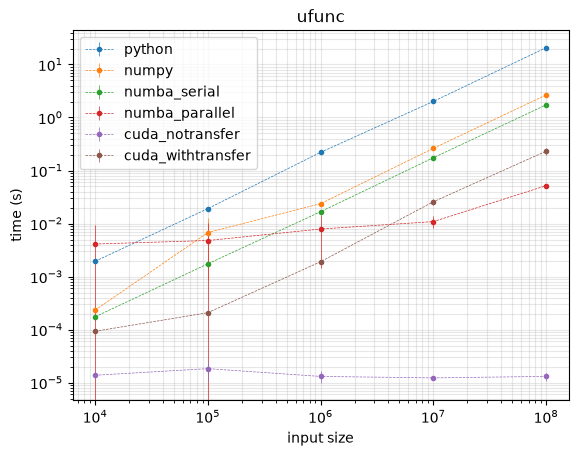

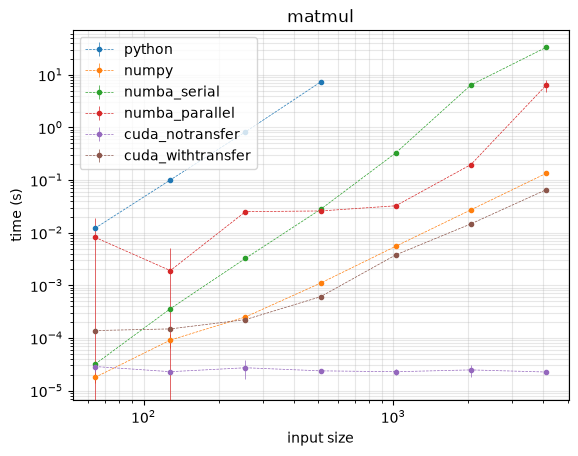

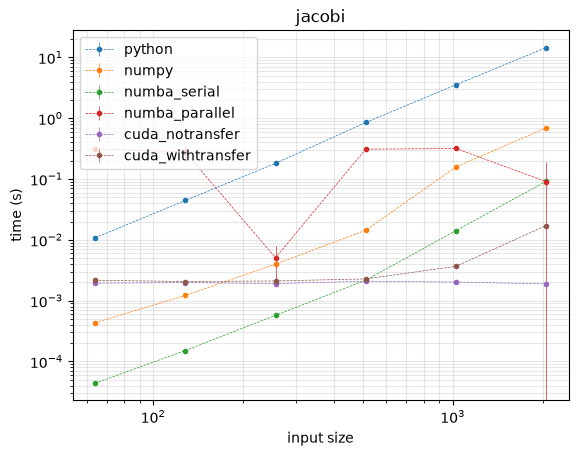

In [7]:
INFILE = "benchmark_results.json"
with open(INFILE, 'r') as f:
    times = json.load(f)

usecases = ["ufunc", "matmul", "jacobi"]
impls = ["python", "numpy", "numba_serial", "numba_parallel", "cuda_notransfer", "cuda_withtransfer"]

def unpack_times(times_dict):
    sizes, ts = zip(*(times_dict.items()))
    avgs, stdevs = zip(*((t["average"], t["stdev"]) for t in ts))
    return np.array([int(s) for s in sizes]), np.array(avgs), np.array(stdevs)

figs = {}
for usecase in usecases:
    fig, ax = plt.subplots()
    figs[usecase] = fig
    for impl in impls:
        sizes, avgs, stdevs = unpack_times(times[usecase][impl])
        ax.errorbar(sizes, avgs, yerr=stdevs, label=impl, ls="--", lw=0.5, marker='.')
    ax.set(xscale="log", yscale="log", xlabel="input size", ylabel="time (s)", title=usecase)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

# Closing remarks

In summary:
- `numpy` allows us to write vectorised code that uses high-performance compiled C routines instead of slow python loops
- `numba` is useful for accelerating code with loops and complex logic, and can also parallelise and improve performance of numpy code
- `cupy` provides a fairly frictionless transition from CPU to GPU computing - useful when you have large data-parallel work that can make effective use of GPUs
- But profile your code - sometimes it's not intuitive which approach gives the best performance.

Coming up next is PyTorch - this provides a numpy-like API for both CPU and GPU computing (including multi-GPU), with additional features to support machine learning applications.

Other related topics we didn't cover today:
- As briefly mentioned, numba also supports GPUs via the `numba-cuda` library
- JAX is another array-oriented library for both CPU and GPU computing, with a machine learning focus
- If you need to scale your Python code beyond a single compute node, you'll need tools for distributed computing - `dask` and `mpi4py` are useful here
